# Dependencies

In [50]:
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

from collections import defaultdict

import yfinance as yf
from datetime import date

%matplotlib inline

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))

tqdm.pandas()

In [5]:
!where python

C:\Users\oluse\anaconda3\envs\udacitydlnndg\python.exe
C:\Users\oluse\AppData\Local\Microsoft\WindowsApps\python.exe


# Get Data

In [7]:
end_date = date.today().strftime("%Y-%m-%d")
print(end_date)
start_date = '2021-02-01'

df = yf.download('BNB-USD', start=start_date, end=end_date)

# Inspect the data
df.head()

2025-01-13


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BNB-USD,BNB-USD,BNB-USD,BNB-USD,BNB-USD
Date,,,,,
2021-02-01,51.607697,52.138683,43.524193,44.309074,1256933735
2021-02-02,51.056404,52.911865,49.387074,51.551884,1006694242
2021-02-03,52.242638,52.677433,49.955585,51.050102,714000888
2021-02-04,55.925125,57.070911,51.602642,52.242210,940905214
2021-02-05,67.845566,68.463959,56.010803,56.010803,1431595319


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2021-02-01 to 2025-01-12
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BNB-USD)   1442 non-null   float64
 1   (High, BNB-USD)    1442 non-null   float64
 2   (Low, BNB-USD)     1442 non-null   float64
 3   (Open, BNB-USD)    1442 non-null   float64
 4   (Volume, BNB-USD)  1442 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 67.6 KB


In [16]:
df.to_csv('../data/BNB-USD.csv', index=False) # save data

In [13]:
close_data = df.Close
# close_data
# close_data.tail()

In [18]:
close_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2021-02-01 to 2025-01-12
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BNB-USD  1442 non-null   float64
dtypes: float64(1)
memory usage: 22.5 KB


We rename the column and index for easy analysis

In [22]:
close_data.rename(columns={'BNB-USD': 'close'}, inplace=True)
close_data.index.name = 'date'


C:\Users\oluse\AppData\Local\Temp\ipykernel_18944\2357904293.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_data.rename(columns={'BNB-USD': 'close'}, inplace=True)


# Visualization

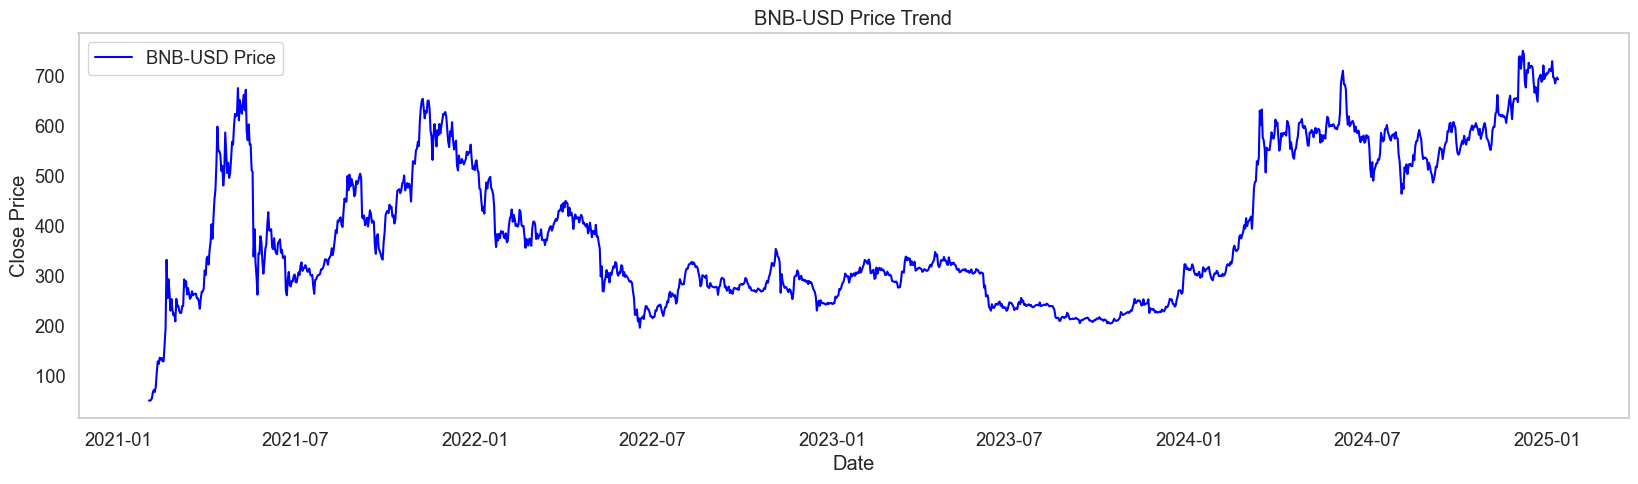

In [31]:
# a. Trend Plot
plt.figure(figsize=(20, 5))
plt.plot(close_data.index, close_data['close'], label='BNB-USD Price', color='blue')
plt.title('BNB-USD Price Trend')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

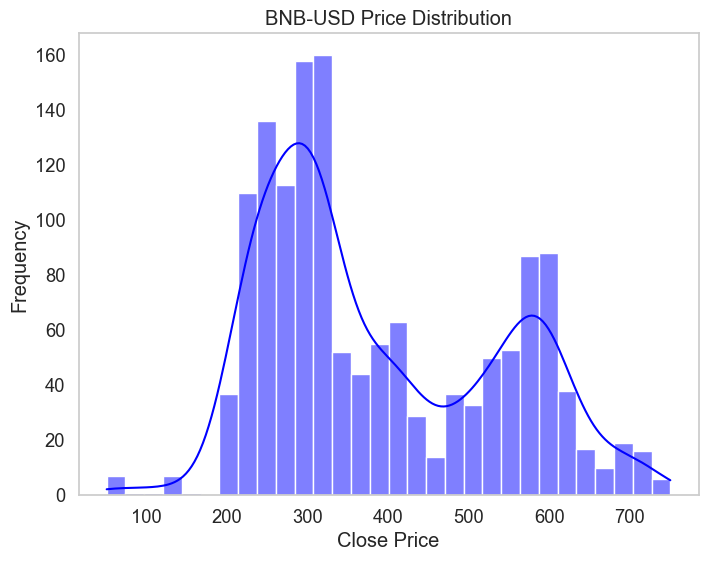

In [29]:
# b. Histogram of Prices
plt.figure(figsize=(8, 6))
sns.histplot(close_data['close'], bins=30, kde=True, color='blue')
plt.title('BNB-USD Price Distribution')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.grid()
plt.show()

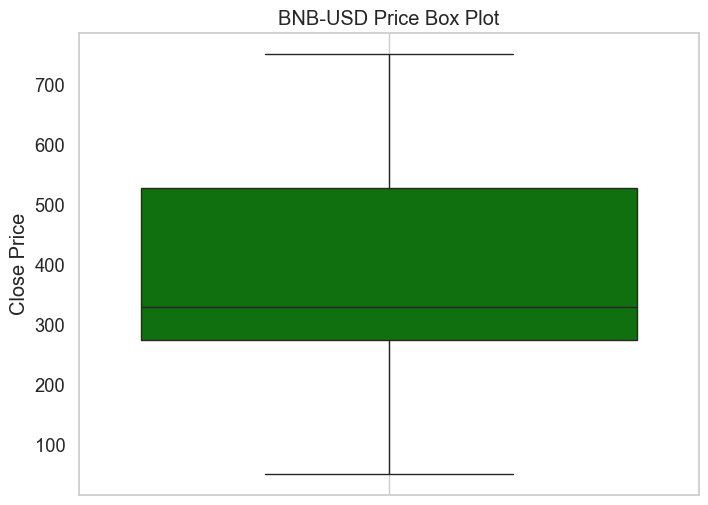

In [28]:
# c. Box Plot to Visualize Outliers
plt.figure(figsize=(8, 6))
sns.boxplot(y=close_data['close'], color='green')
plt.title('BNB-USD Price Box Plot')
plt.ylabel('Close Price')
plt.grid()
plt.show()

C:\Users\oluse\AppData\Local\Temp\ipykernel_18944\71740514.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_data['rolling_mean'] = close_data['close'].rolling(window=30).mean()  # 30-day rolling mean
C:\Users\oluse\AppData\Local\Temp\ipykernel_18944\71740514.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_data['rolling_std'] = close_data['close'].rolling(window=30).std()    # 30-day rolling std


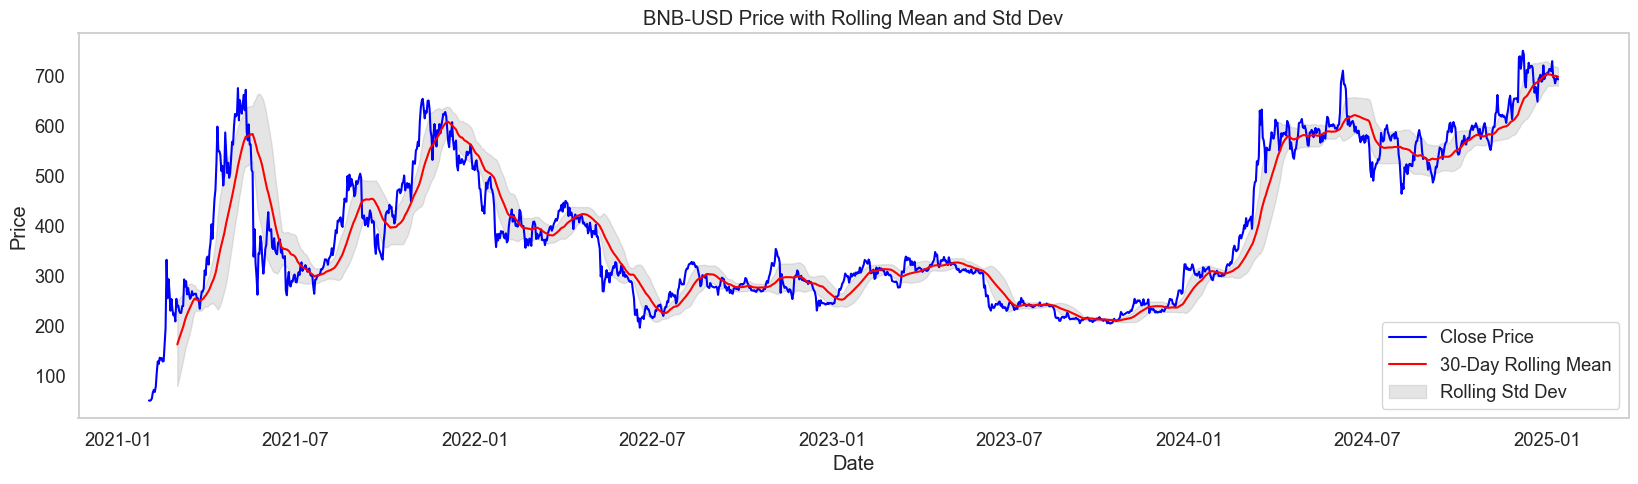

In [33]:
# d. Rolling Average and Volatility
close_data['rolling_mean'] = close_data['close'].rolling(window=30).mean()  # 30-day rolling mean
close_data['rolling_std'] = close_data['close'].rolling(window=30).std()    # 30-day rolling std

plt.figure(figsize=(20, 5))
plt.plot(close_data.index, close_data['close'], label='Close Price', color='blue')
plt.plot(close_data.index, close_data['rolling_mean'], label='30-Day Rolling Mean', color='red')
plt.fill_between(close_data.index,
                 close_data['rolling_mean'] - close_data['rolling_std'],
                 close_data['rolling_mean'] + close_data['rolling_std'],
                 color='gray', alpha=0.2, label='Rolling Std Dev')
plt.title('BNB-USD Price with Rolling Mean and Std Dev')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

In [34]:
close_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2021-02-01 to 2025-01-12
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   close         1442 non-null   float64
 1   rolling_mean  1413 non-null   float64
 2   rolling_std   1413 non-null   float64
dtypes: float64(3)
memory usage: 45.1 KB


# Feature Engineering

In [61]:
# Feature Engineering
def create_features(data):
    """
    Create lag and rolling features for the time series data.
    """
    data['lag_1'] = data['close'].shift(1)
    data['lag_2'] = data['close'].shift(2)
    data['lag_3'] = data['close'].shift(3)
    data['rolling_mean_3'] = data['close'].rolling(window=3).mean()
    data['rolling_std_3'] = data['close'].rolling(window=3).std()
    data['rolling_mean_7'] = data['close'].rolling(window=7).mean()
    return data

close_data = create_features(close_data)

# Drop rows with NaN values due to feature creation
close_data.dropna(inplace=True)

# Define features (X) and target (y)
X = close_data[['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_7']]
y = close_data['close'].values


# Train XGBoost model

In [63]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Convert to DMatrix (XGBoost-specific format)
train_dmatrix = xgb.DMatrix(X_train, label=y_train)
test_dmatrix = xgb.DMatrix(X_test, label=y_test)

# XGBoost parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 5,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'eval_metric': 'rmse'
}

# Train the model
xgb_model = xgb.train(
    params=params,
    dtrain=train_dmatrix,
    num_boost_round=100,
    evals=[(train_dmatrix, 'train'), (test_dmatrix, 'eval')],
    early_stopping_rounds=10
)

# Make predictions
y_pred = xgb_model.predict(test_dmatrix)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

[0]	train-rmse:97.75209	eval-rmse:237.23594
[1]	train-rmse:88.30911	eval-rmse:216.09257
[2]	train-rmse:79.81544	eval-rmse:197.11545
[3]	train-rmse:72.15097	eval-rmse:179.96298
[4]	train-rmse:65.25703	eval-rmse:164.43352
[5]	train-rmse:59.06146	eval-rmse:150.38922
[6]	train-rmse:53.48056	eval-rmse:138.11539
[7]	train-rmse:48.46436	eval-rmse:126.83344
[8]	train-rmse:43.94500	eval-rmse:116.64356
[9]	train-rmse:39.88412	eval-rmse:107.47793
[10]	train-rmse:36.25087	eval-rmse:99.37629
[11]	train-rmse:32.96556	eval-rmse:91.99680
[12]	train-rmse:30.02777	eval-rmse:85.44011
[13]	train-rmse:27.38212	eval-rmse:79.54695
[14]	train-rmse:25.00686	eval-rmse:74.07359
[15]	train-rmse:22.87612	eval-rmse:69.26450
[16]	train-rmse:20.96582	eval-rmse:65.08918
[17]	train-rmse:19.25083	eval-rmse:61.01188
[18]	train-rmse:17.70932	eval-rmse:57.24393
[19]	train-rmse:16.34497	eval-rmse:54.18305
[20]	train-rmse:15.12640	eval-rmse:51.49032
[21]	train-rmse:14.03537	eval-rmse:48.76581
[22]	train-rmse:13.05163	eval-rm

C:\Users\oluse\anaconda3\envs\udacitydlnndg\Lib\site-packages\xgboost\core.py:158: UserWarning: [09:48:52] WARNING: D:\bld\xgboost-split_1733179550881\work\src\learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[38]	train-rmse:6.23637	eval-rmse:33.83208
[39]	train-rmse:6.09990	eval-rmse:33.49794
[40]	train-rmse:5.97794	eval-rmse:33.16540
[41]	train-rmse:5.86081	eval-rmse:33.24381
[42]	train-rmse:5.76032	eval-rmse:33.16130
[43]	train-rmse:5.64109	eval-rmse:32.98795
[44]	train-rmse:5.54907	eval-rmse:32.67176
[45]	train-rmse:5.45256	eval-rmse:32.52677
[46]	train-rmse:5.38624	eval-rmse:32.33877
[47]	train-rmse:5.29931	eval-rmse:32.22762
[48]	train-rmse:5.23436	eval-rmse:32.01949
[49]	train-rmse:5.17059	eval-rmse:31.89471
[50]	train-rmse:5.09899	eval-rmse:31.81992
[51]	train-rmse:5.04705	eval-rmse:31.75958
[52]	train-rmse:5.00283	eval-rmse:31.76665
[53]	train-rmse:4.95472	eval-rmse:31.72163
[54]	train-rmse:4.91287	eval-rmse:31.60445
[55]	train-rmse:4.87301	eval-rmse:31.60466
[56]	train-rmse:4.82851	eval-rmse:31.51057
[57]	train-rmse:4.78582	eval-rmse:31.44808
[58]	train-rmse:4.74000	eval-rmse:31.41071
[59]	train-rmse:4.69170	eval-rmse:31.31675
[60]	train-rmse:4.65901	eval-rmse:31.30134
[61]	train-

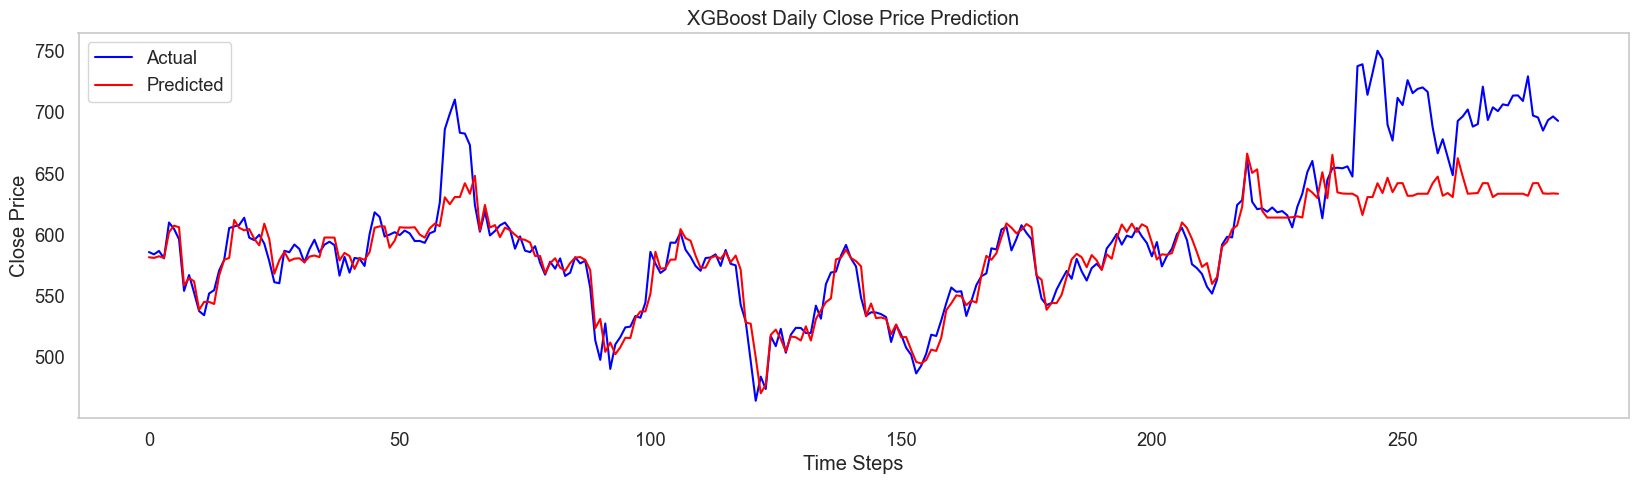

In [65]:
# Plot actual vs predicted
plt.figure(figsize=(20, 5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title('XGBoost Daily Close Price Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

# Hyperparameter tuning: XGBoost

In [66]:
# Define a function for hyperparameter tuning
def tune_xgboost(X_train, y_train):
    """
    Perform hyperparameter tuning for XGBoost using GridSearchCV.
    """
    # Create an XGBoost regressor
    xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

    # Define the parameter grid
    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [50, 100, 200],
        'subsample': [0.8, 1],
        'colsample_bytree': [0.8, 1]
    }

    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=xgb_regressor,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=3,
        verbose=1,
        n_jobs=-1
    )

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Return the best model and parameters
    return grid_search.best_estimator_, grid_search.best_params_

In [67]:
# Perform hyperparameter tuning
best_model, best_params = tune_xgboost(X_train, y_train)

# Evaluate the best model on the test set
y_pred_best = best_model.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"Best Parameters: {best_params}")
print(f"RMSE with Best Parameters: {rmse_best}")

# Compare with the default model
default_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
default_model.fit(X_train, y_train)
y_pred_default = default_model.predict(X_test)
rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_default))
print(f"RMSE with Default Parameters: {rmse_default}")

# Compare results
print(f"Improvement in RMSE: {rmse_default - rmse_best}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
RMSE with Best Parameters: 28.16590694343853
RMSE with Default Parameters: 31.416035604437305
Improvement in RMSE: 3.250128660998776


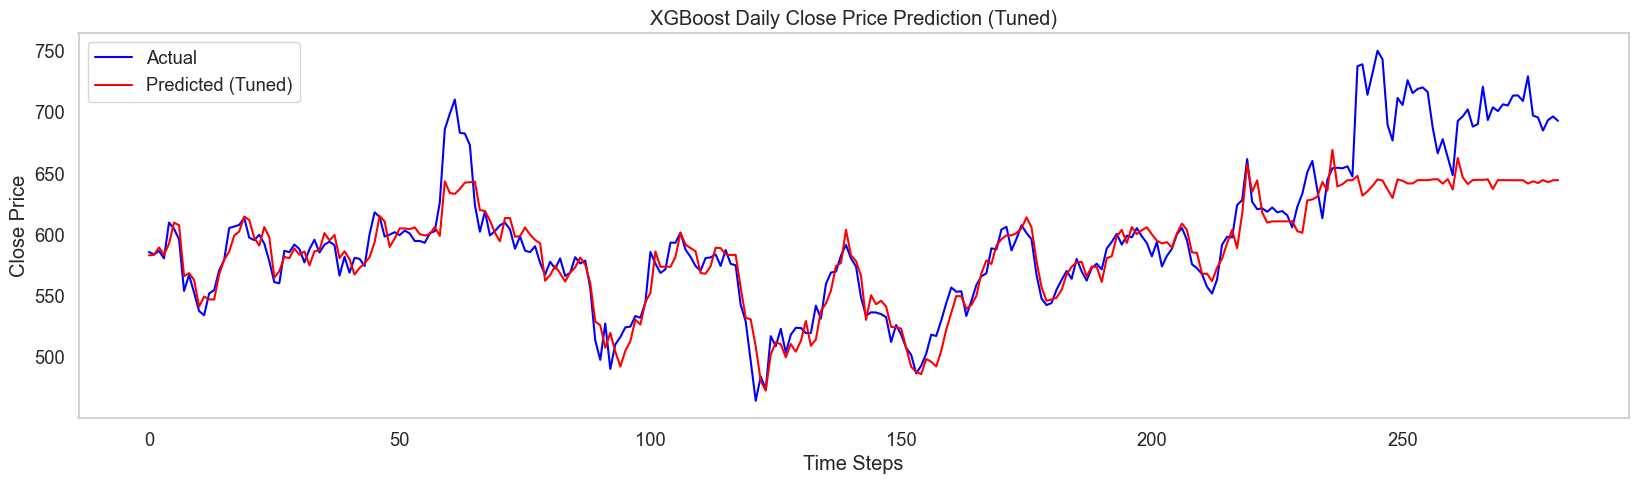

In [83]:
# Plot the predictions of the tuned model
plt.figure(figsize=(20, 5))
plt.plot(y_test, label='Actual', color='blue')
# plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred_best, label='Predicted (Tuned)', color='red')
plt.title('XGBoost Daily Close Price Prediction (Tuned)')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

# LSTM

In [69]:
# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape data for LSTM input (samples, time_steps, features)
X_scaled = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle=False)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [70]:
# LSTM Model Definition
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.fc = nn.Linear(hidden_layer_size, output_size)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        predictions = self.fc(lstm_out[:, -1, :])  # Take the last time step output
        return predictions

In [71]:
# Hyperparameter Tuning (GridSearchCV won't work directly with PyTorch, we will manually try different parameters)
def train_lstm_model(hidden_layer_size, num_epochs=100, batch_size=32, learning_rate=0.001):
    model = LSTMModel(input_size=X_train.shape[2], hidden_layer_size=hidden_layer_size)
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Train the model
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass
        output = model(X_train_tensor)
        loss = loss_function(output.squeeze(), y_train_tensor)

        # Backward pass
        loss.backward()
        optimizer.step()

    # Evaluate the model
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor).squeeze()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred.numpy()))
    return rmse

In [77]:
# Hyperparameter Tuning: Trying different configurations manually
hidden_layer_sizes = [100, 200, 300, 450, 600]
learning_rates = [ 0.01, 0.1, 0.25, 0.5, 0.65]
num_epochs = 50

best_rmse = float('inf')
best_params = {}

for hidden_layer_size in hidden_layer_sizes:
    for learning_rate in learning_rates:
        print(f"Training with hidden layer size: {hidden_layer_size}, learning rate: {learning_rate}")
        rmse = train_lstm_model(hidden_layer_size, num_epochs, learning_rate=learning_rate)
        print(f"RMSE: {rmse}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = {'hidden_layer_size': hidden_layer_size, 'learning_rate': learning_rate}

print(f"Best Hyperparameters: {best_params}")
print(f"Best RMSE: {best_rmse}")

Training with hidden layer size: 100, learning rate: 0.01
RMSE: 592.6884910480521
Training with hidden layer size: 100, learning rate: 0.1
RMSE: 258.1915645916757
Training with hidden layer size: 100, learning rate: 0.25
RMSE: 104.1409675428386
Training with hidden layer size: 100, learning rate: 0.5
RMSE: 62.32326199720457
Training with hidden layer size: 100, learning rate: 0.65
RMSE: 65.29486944378203
Training with hidden layer size: 200, learning rate: 0.01
RMSE: 589.809143097069
Training with hidden layer size: 200, learning rate: 0.1
RMSE: 113.00365748267201
Training with hidden layer size: 200, learning rate: 0.25
RMSE: 86.77889553487545
Training with hidden layer size: 200, learning rate: 0.5
RMSE: 56.26366756134538
Training with hidden layer size: 200, learning rate: 0.65
RMSE: 61.6492636917652
Training with hidden layer size: 300, learning rate: 0.01
RMSE: 581.5108409592438
Training with hidden layer size: 300, learning rate: 0.1
RMSE: 93.40739614404656
Training with hidden l

Final RMSE: 34.61466601058719


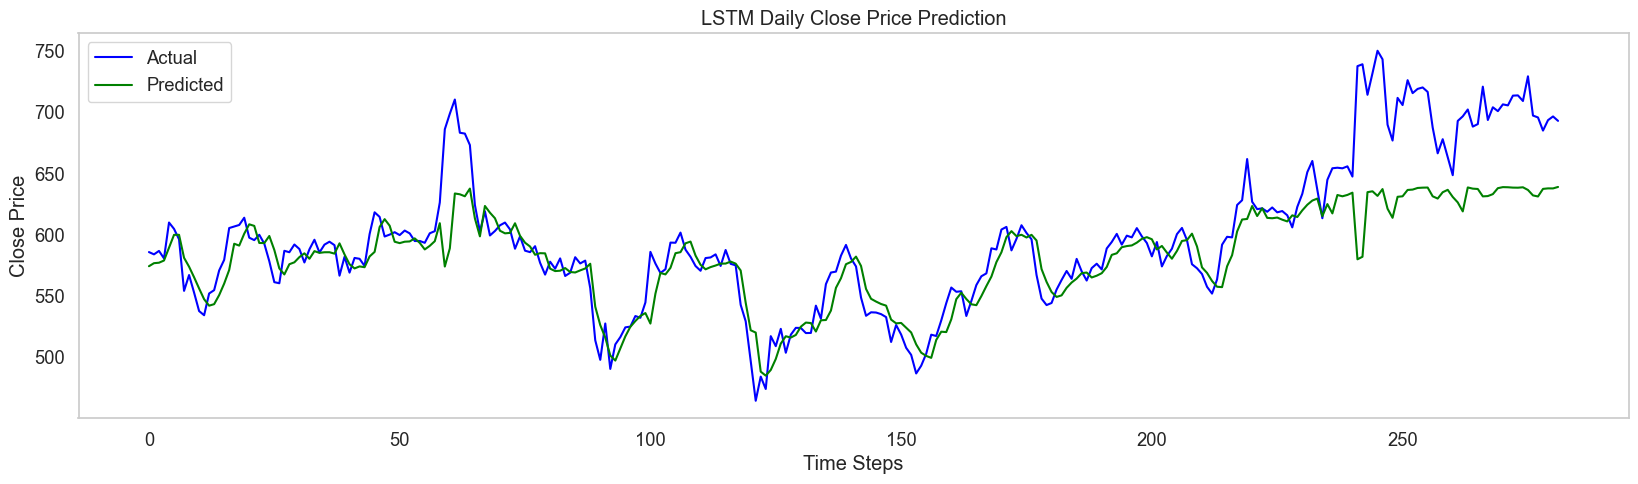

In [78]:
# Final Model with Best Hyperparameters
final_model = LSTMModel(input_size=X_train.shape[2], hidden_layer_size=best_params['hidden_layer_size'])
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['learning_rate'])

# Train the final model
final_model.train()
for epoch in range(num_epochs):
    final_model.train()
    optimizer.zero_grad()
    output = final_model(X_train_tensor)
    loss = loss_function(output.squeeze(), y_train_tensor)
    loss.backward()
    optimizer.step()

# Evaluate the final model
final_model.eval()
with torch.no_grad():
    y_pred_final = final_model(X_test_tensor).squeeze()

# Calculate RMSE for the final model
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final.numpy()))
print(f"Final RMSE: {final_rmse}")

# Plot actual vs predicted
plt.figure(figsize=(20, 5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_final.numpy(), label='Predicted', color='green')
plt.title('LSTM Daily Close Price Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

# Comparison plot

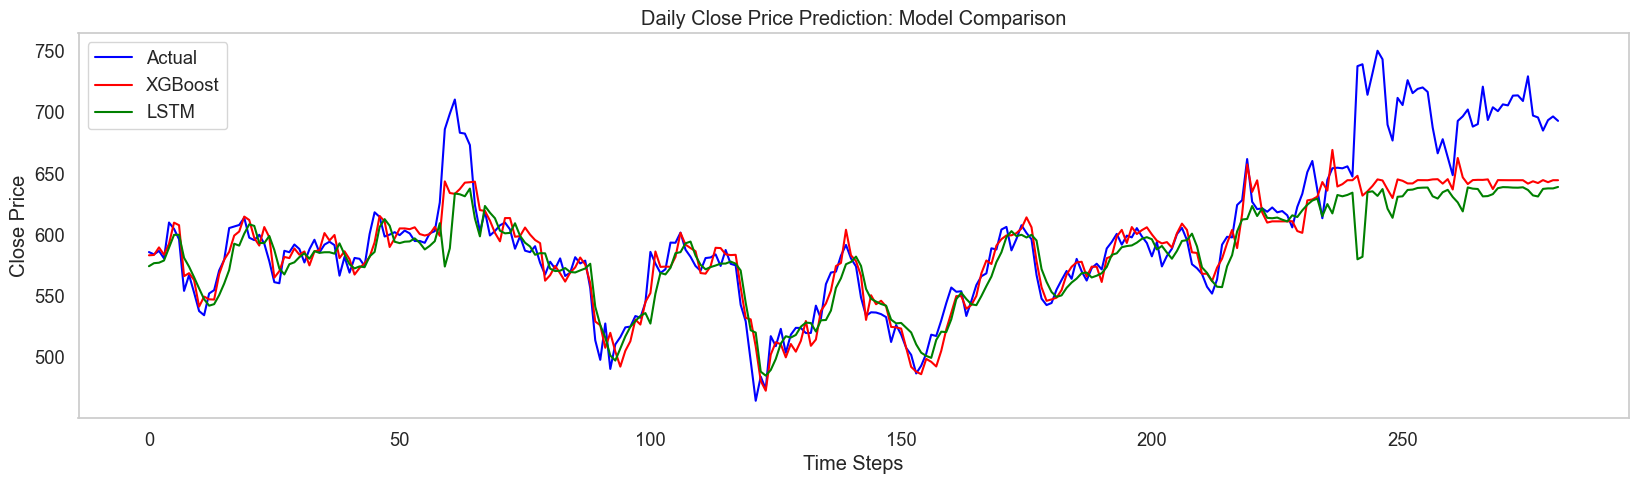

In [82]:
# Plot actual vs predicted
plt.figure(figsize=(20, 5))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred_best, label='XGBoost', color='red')
plt.plot(y_pred_final.numpy(), label='LSTM', color='green')
plt.title('Daily Close Price Prediction: Model Comparison')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()